In [ ]:
"""
Liver Disease Prediction System - Backend Implementation
CSV-based Machine Learning Pipeline
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')


In [ ]:
class LiverDiseasePredictor:
    def __init__(self, csv_path=None):
        self.csv_path = csv_path
        self.df = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.X_train_scaled = None
        self.X_test_scaled = None

        self.scaler = StandardScaler()
        self.models = {}
        self.results = {}

        self.best_model = None
        self.best_model_name = None

        self.feature_names = None
        self.encoders = {}


In [ ]:
    def load_dataset(self, csv_path=None):
        if csv_path:
            self.csv_path = csv_path

        print("STEP 1: LOADING DATASET")

        self.df = pd.read_csv(self.csv_path)
        print("Dataset loaded successfully")
        print("Shape:", self.df.shape)

        display(self.df.head())
        display(self.df.describe())

        return self.df


In [ ]:
    def exploratory_data_analysis(self):
        print("\nSTEP 2: EXPLORATORY DATA ANALYSIS")

        print("\nMissing values:")
        display(self.df.isnull().sum())

        possible_targets = ['Dataset', 'Result', 'Target', 'Diagnosis', 'Class']
        target_col = None

        for col in self.df.columns:
            if col in possible_targets or 'disease' in col.lower():
                target_col = col
                break

        if target_col is None:
            target_col = self.df.columns[-1]

        print("\nTarget column identified:", target_col)
        display(self.df[target_col].value_counts())

        return target_col


In [ ]:
    def preprocess_data(self, target_column, test_size=0.2):
        print("\nSTEP 3: DATA PREPROCESSING")

        X = self.df.drop(columns=[target_column])
        y = self.df[target_column]

        # Encode categorical features
        cat_cols = X.select_dtypes(include='object').columns
        for col in cat_cols:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            self.encoders[col] = le

        # Handle missing values
        imputer = SimpleImputer(strategy='median')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

        # Encode target if needed
        if y.dtype == 'object':
            y = LabelEncoder().fit_transform(y)

        self.feature_names = X.columns.tolist()

        # Train-test split
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )

        # Scaling
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        print("Preprocessing completed successfully")


In [ ]:
    def train_models(self):
        print("\nSTEP 4: TRAINING MODELS")

        self.models = {
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "KNN": KNeighborsClassifier(n_neighbors=5),
            "SVM": SVC(kernel='rbf', probability=True),
            "Random Forest": RandomForestClassifier(n_estimators=100)
        }

        for name, model in self.models.items():
            model.fit(self.X_train_scaled, self.y_train)
            print(f"{name} trained successfully")



In [ ]:
    def evaluate_models(self):
        print("\nSTEP 5: MODEL EVALUATION")

        for name, model in self.models.items():
            y_pred = model.predict(self.X_test_scaled)

            acc = accuracy_score(self.y_test, y_pred)
            prec = precision_score(self.y_test, y_pred, average='weighted')
            rec = recall_score(self.y_test, y_pred, average='weighted')
            f1 = f1_score(self.y_test, y_pred, average='weighted')

            self.results[name] = acc

            print(f"\n{name}")
            print("Accuracy:", acc)
            print("Precision:", prec)
            print("Recall:", rec)
            print("F1-score:", f1)
            print("Confusion Matrix:\n", confusion_matrix(self.y_test, y_pred))

        self.best_model_name = max(self.results, key=self.results.get)
        self.best_model = self.models[self.best_model_name]

        print("\nBest Model:", self.best_model_name)


In [ ]:
    def predict_new_patient(self, patient_data):
        if isinstance(patient_data, dict):
            patient_data = pd.DataFrame([patient_data])

        patient_data = patient_data[self.feature_names]

        for col, encoder in self.encoders.items():
            patient_data[col] = encoder.transform(patient_data[col].astype(str))

        patient_scaled = self.scaler.transform(patient_data)

        prediction = self.best_model.predict(patient_scaled)[0]
        confidence = self.best_model.predict_proba(patient_scaled)[0][prediction]

        return prediction, confidence


In [ ]:
    def run_complete_pipeline(self):
        self.load_dataset()
        target_col = self.exploratory_data_analysis()
        self.preprocess_data(target_col)
        self.train_models()
        self.evaluate_models()


In [ ]:
class LiverDiseasePredictor:

    def __init__(self, csv_path=None):
        self.csv_path = csv_path
        self.df = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.X_train_scaled = None
        self.X_test_scaled = None

        from sklearn.preprocessing import StandardScaler
        self.scaler = StandardScaler()

        self.models = {}
        self.results = {}

        self.best_model = None
        self.best_model_name = None

        self.feature_names = None
        self.encoders = {}

    def load_dataset(self):
        import pandas as pd
        self.df = pd.read_csv(self.csv_path)
        print("Dataset loaded:", self.df.shape)
        return self.df

    def exploratory_data_analysis(self):
        print("\nEDA running...")
        target_col = self.df.columns[-1]
        print("Target column:", target_col)
        print(self.df[target_col].value_counts())
        return target_col

    def preprocess_data(self, target_column):
        import pandas as pd
        from sklearn.preprocessing import LabelEncoder
        from sklearn.impute import SimpleImputer
        from sklearn.model_selection import train_test_split

        X = self.df.drop(columns=[target_column])
        y = self.df[target_column]

        cat_cols = X.select_dtypes(include='object').columns
        for col in cat_cols:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            self.encoders[col] = le

        imputer = SimpleImputer(strategy='median')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

        if y.dtype == 'object':
            y = LabelEncoder().fit_transform(y)

        self.feature_names = X.columns.tolist()

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        print("Preprocessing done")

    def train_models(self):
        from sklearn.linear_model import LogisticRegression
        from sklearn.neighbors import KNeighborsClassifier
        from sklearn.svm import SVC
        from sklearn.ensemble import RandomForestClassifier

        self.models = {
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "KNN": KNeighborsClassifier(),
            "SVM": SVC(probability=True),
            "Random Forest": RandomForestClassifier()
        }

        for name, model in self.models.items():
            model.fit(self.X_train_scaled, self.y_train)
            print(name, "trained")

    def evaluate_models(self):
        from sklearn.metrics import accuracy_score

        best_acc = 0

        for name, model in self.models.items():
            preds = model.predict(self.X_test_scaled)
            acc = accuracy_score(self.y_test, preds)
            print(name, "accuracy:", acc)

            if acc > best_acc:
                best_acc = acc
                self.best_model = model
                self.best_model_name = name

        print("Best model:", self.best_model_name)

    def run_complete_pipeline(self):
        self.load_dataset()
        target = self.exploratory_data_analysis()
        self.preprocess_data(target)
        self.train_models()
        self.evaluate_models()


In [ ]:
dir(LiverDiseasePredictor)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'evaluate_models',
 'exploratory_data_analysis',
 'load_dataset',
 'preprocess_data',
 'run_complete_pipeline',
 'train_models']

In [ ]:
predictor = LiverDiseasePredictor("/kaggle/input/indian-liver-patient-records/indian_liver_patient.csv")
predictor.run_complete_pipeline()

Dataset loaded: (583, 11)

EDA running...
Target column: Dataset
Dataset
1    416
2    167
Name: count, dtype: int64
Preprocessing done
Logistic Regression trained
KNN trained
SVM trained
Random Forest trained
Logistic Regression accuracy: 0.6923076923076923
KNN accuracy: 0.6410256410256411
SVM accuracy: 0.6837606837606838
Random Forest accuracy: 0.6410256410256411
Best model: Logistic Regression


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive


 24BAI70365_ADITYACHHIKARA_LINEARALGEBRA.pdf
'24BAI70365 HungerShield.pptx'
 24BAI70365.pdf
 24BAI70365.ttt
 24BAI70387.ttt
'aditya pattern.txt'
'ADITYA ROBOT (1).ttt'
'ADITYA ROBOT.ttt'
'aditya work college'
 AI_DISEASE_DETECTION_PESTCONTROL.docx
'Colab Notebooks'
'Copy of DSA SHEET.gsheet'
 IMG_2770.png
'Literature Review of 20 Papers'$'\n''.gdoc'
 tutorials
'WhatsApp Image 2025-07-04 at 10.30.33_908480ac.jpg'


In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/indian-liver-patient-records")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'indian-liver-patient-records' dataset.
Path to dataset files: /kaggle/input/indian-liver-patient-records


In [ ]:
class LiverDiseasePredictor(LiverDiseasePredictor):

    def predict_new_patient(self, patient_data):
        """
        Predict liver disease for a new patient
        """

        import pandas as pd
        import numpy as np

        if self.best_model is None:
            raise Exception("Model not trained. Run pipeline first.")

        # Convert dict to DataFrame
        if isinstance(patient_data, dict):
            patient_data = pd.DataFrame([patient_data])

        # Ensure correct column order
        patient_data = patient_data[self.feature_names]

        # Encode categorical features
        for col, encoder in self.encoders.items():
            patient_data[col] = encoder.transform(
                patient_data[col].astype(str)
            )

        # Scale data
        patient_scaled = self.scaler.transform(patient_data)

        # Prediction
        prediction = self.best_model.predict(patient_scaled)[0]

        # Confidence (if available)
        if hasattr(self.best_model, "predict_proba"):
            confidence = self.best_model.predict_proba(patient_scaled)[0][prediction]
        else:
            confidence = None

        return prediction, confidence


In [ ]:
dir(LiverDiseasePredictor)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'evaluate_models',
 'exploratory_data_analysis',
 'load_dataset',
 'predict_new_patient',
 'preprocess_data',
 'run_complete_pipeline',
 'train_models']

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
def predict_new_patient(self, patient_data):
    """
    Predict liver disease for a new patient using trained ML model

    Parameters:
    patient_data : dict or pandas DataFrame

    Returns:
    prediction : int
    confidence : float
    """

    if self.best_model is None:
        raise Exception("Model is not trained yet!")

    # Convert dict to DataFrame
    if isinstance(patient_data, dict):
        patient_data = pd.DataFrame([patient_data])

    # Copy to avoid modifying original
    patient_data = patient_data.copy()

    # Encode categorical columns using trained encoders
    for col, encoder in self.encoders.items():
        if col in patient_data.columns:
            patient_data[col] = encoder.transform(
                patient_data[col].astype(str)
            )

    # Ensure same feature order as training
    patient_data = patient_data[self.feature_names]

    # Scale features
    patient_scaled = self.scaler.transform(patient_data)

    # Make prediction
    prediction = self.best_model.predict(patient_scaled)[0]

    # Confidence score
    if hasattr(self.best_model, "predict_proba"):
        confidence = self.best_model.predict_proba(patient_scaled)[0][prediction]
    else:
        confidence = None

    return prediction, confidence


In [ ]:
predictor = LiverDiseasePredictor("/kaggle/input/indian-liver-patient-records/indian_liver_patient.csv")
predictor.run_complete_pipeline()

Dataset loaded: (583, 11)

EDA running...
Target column: Dataset
Dataset
1    416
2    167
Name: count, dtype: int64
Preprocessing done
Logistic Regression trained
KNN trained
SVM trained
Random Forest trained
Logistic Regression accuracy: 0.6923076923076923
KNN accuracy: 0.6410256410256411
SVM accuracy: 0.6837606837606838
Random Forest accuracy: 0.6581196581196581
Best model: Logistic Regression


In [ ]:
class LiverDiseasePredictor:

    def __init__(self, csv_path):
        self.csv_path = csv_path
        self.df = None
        self.scaler = StandardScaler()
        self.models = {}
        self.best_model = None
        self.encoders = {}
        self.feature_names = None

    def load_dataset(self):
        self.df = pd.read_csv(self.csv_path)
        return self.df

    def exploratory_data_analysis(self):
        for col in self.df.columns:
            if "disease" in col.lower() or col.lower() == "dataset":
                return col
        return self.df.columns[-1]

    def preprocess_data(self, target_col):
        X = self.df.drop(columns=[target_col])
        y = self.df[target_col]

        # Encode categorical columns
        for col in X.select_dtypes(include="object").columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            self.encoders[col] = le

        # Handle missing values
        imputer = SimpleImputer(strategy="median")
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

        self.feature_names = X.columns.tolist()

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        self.X_train = self.scaler.fit_transform(X_train)
        self.X_test = self.scaler.transform(X_test)
        self.y_train = y_train
        self.y_test = y_test

    def train_models(self):
        self.models = {
            "Random Forest": RandomForestClassifier(random_state=42)
        }
        self.models["Random Forest"].fit(self.X_train, self.y_train)
        self.best_model = self.models["Random Forest"]

    def run_complete_pipeline(self):
        self.load_dataset()
        target = self.exploratory_data_analysis()
        self.preprocess_data(target)
        self.train_models()

    # 🔥 FINAL, SAFE PREDICTION METHOD
    def predict_new_patient(self, patient_data):

        if self.best_model is None:
            raise Exception("Model not trained yet!")

        # Convert dict to DataFrame
        if isinstance(patient_data, dict):
            patient_data = pd.DataFrame([patient_data])

        patient_data = patient_data.copy()

        # Add missing columns
        for col in self.feature_names:
            if col not in patient_data.columns:
                patient_data[col] = np.nan

        # Reorder columns
        patient_data = patient_data[self.feature_names]

        # 🔐 SAFE categorical encoding
        for col, encoder in self.encoders.items():
            if col in patient_data.columns:
                patient_data[col] = patient_data[col].astype(str)

                known_classes = set(encoder.classes_)
                patient_data[col] = patient_data[col].apply(
                    lambda x: x if x in known_classes else encoder.classes_[0]
                )

                patient_data[col] = encoder.transform(patient_data[col])

        # Replace remaining NaNs with 0
        patient_data = patient_data.fillna(0)

        # Scale
        patient_scaled = self.scaler.transform(patient_data)

        # Predict
        prediction = self.best_model.predict(patient_scaled)[0]
        proba = self.best_model.predict_proba(patient_scaled)[0]
        class_index = list(self.best_model.classes_).index(prediction)
        confidence = proba[class_index]


        return prediction, confidence


In [ ]:
predictor = LiverDiseasePredictor("/kaggle/input/indian-liver-patient-records/indian_liver_patient.csv")
predictor.run_complete_pipeline()

In [ ]:
print("Training features:")
print(predictor.feature_names)


Training features:
['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']


In [ ]:
sample_patient = {
    "Age": 65,
    "Gender": "Female",
    "Total_Bilirubin": 0.7,
    "Direct_Bilirubin": 0.1,
    "Alkaline_Phosphotase": 187,
    "Alamine_Aminotransferase": 16,
    "Aspartate_Aminotransferase": 18,
    "Total_Proteins": 6.8,
    "Albumin": 3.3,
    "Albumin_and_Globulin_Ratio": 0.9
}

prediction, confidence = predictor.predict_new_patient(sample_patient)

print("Prediction:", "Liver Disease" if prediction == 1 else "No Liver Disease")
print("Confidence:", round(confidence * 100, 2), "%")


Prediction: Liver Disease
Confidence: 55.0 %


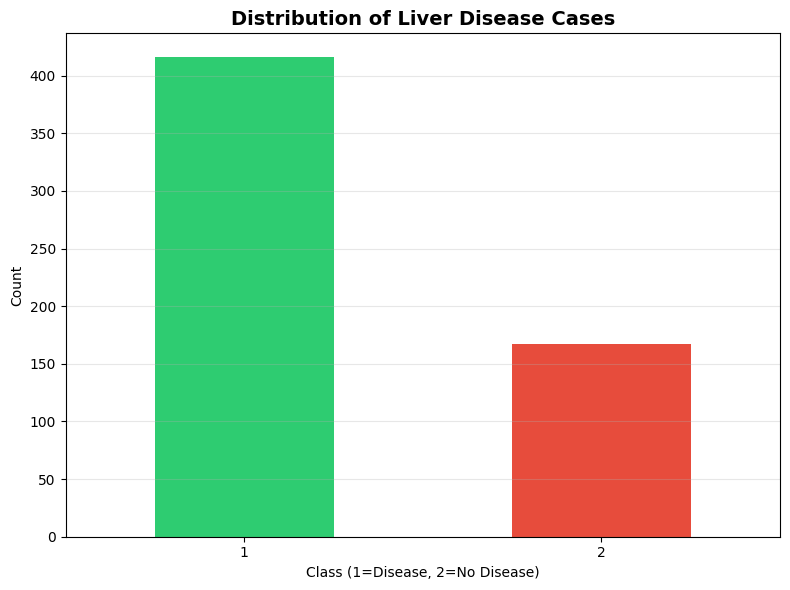

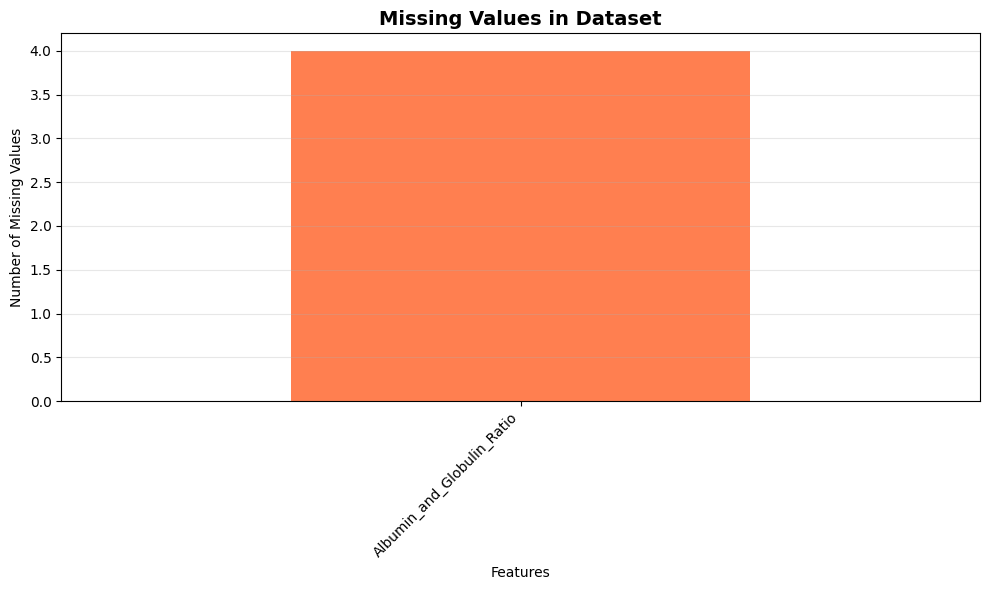

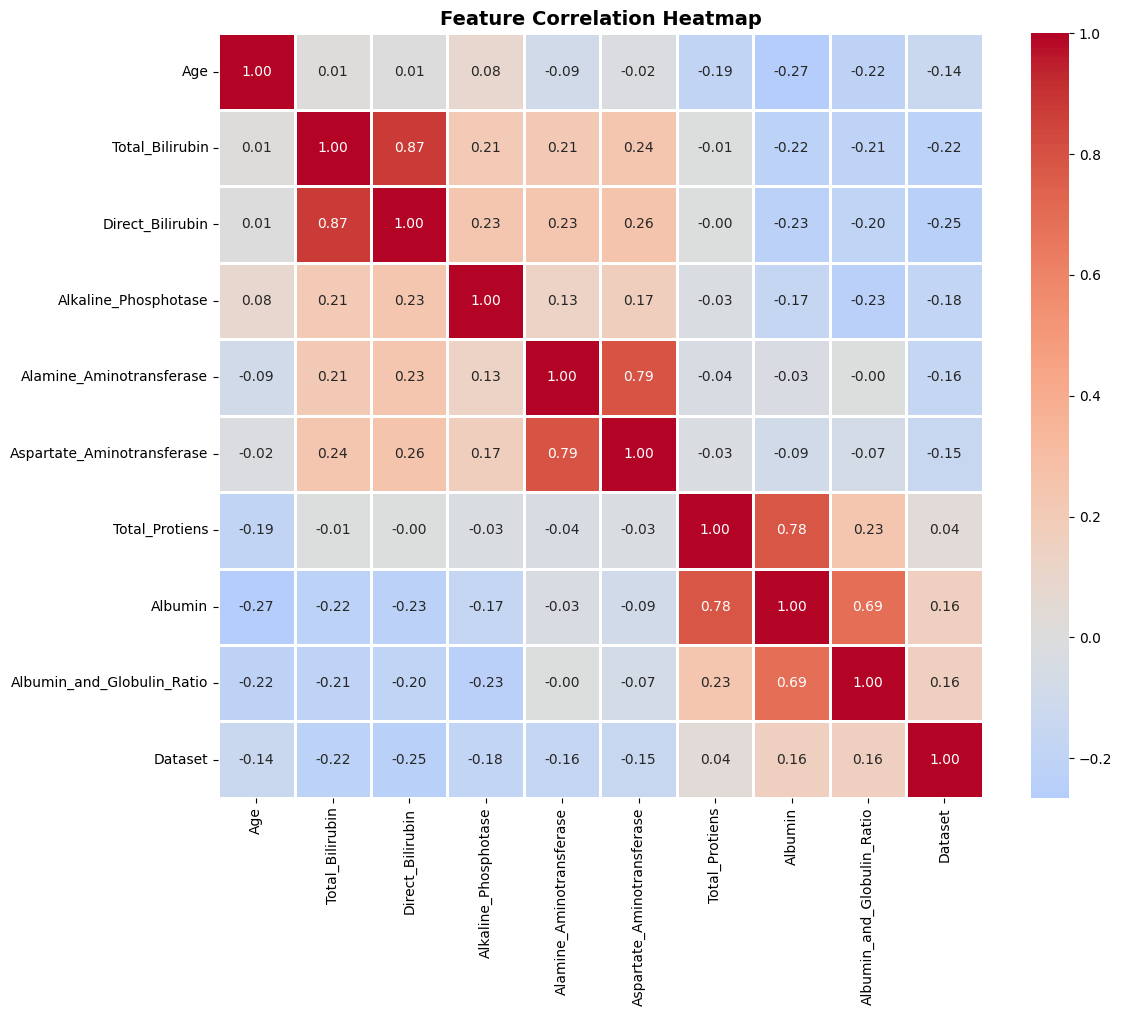

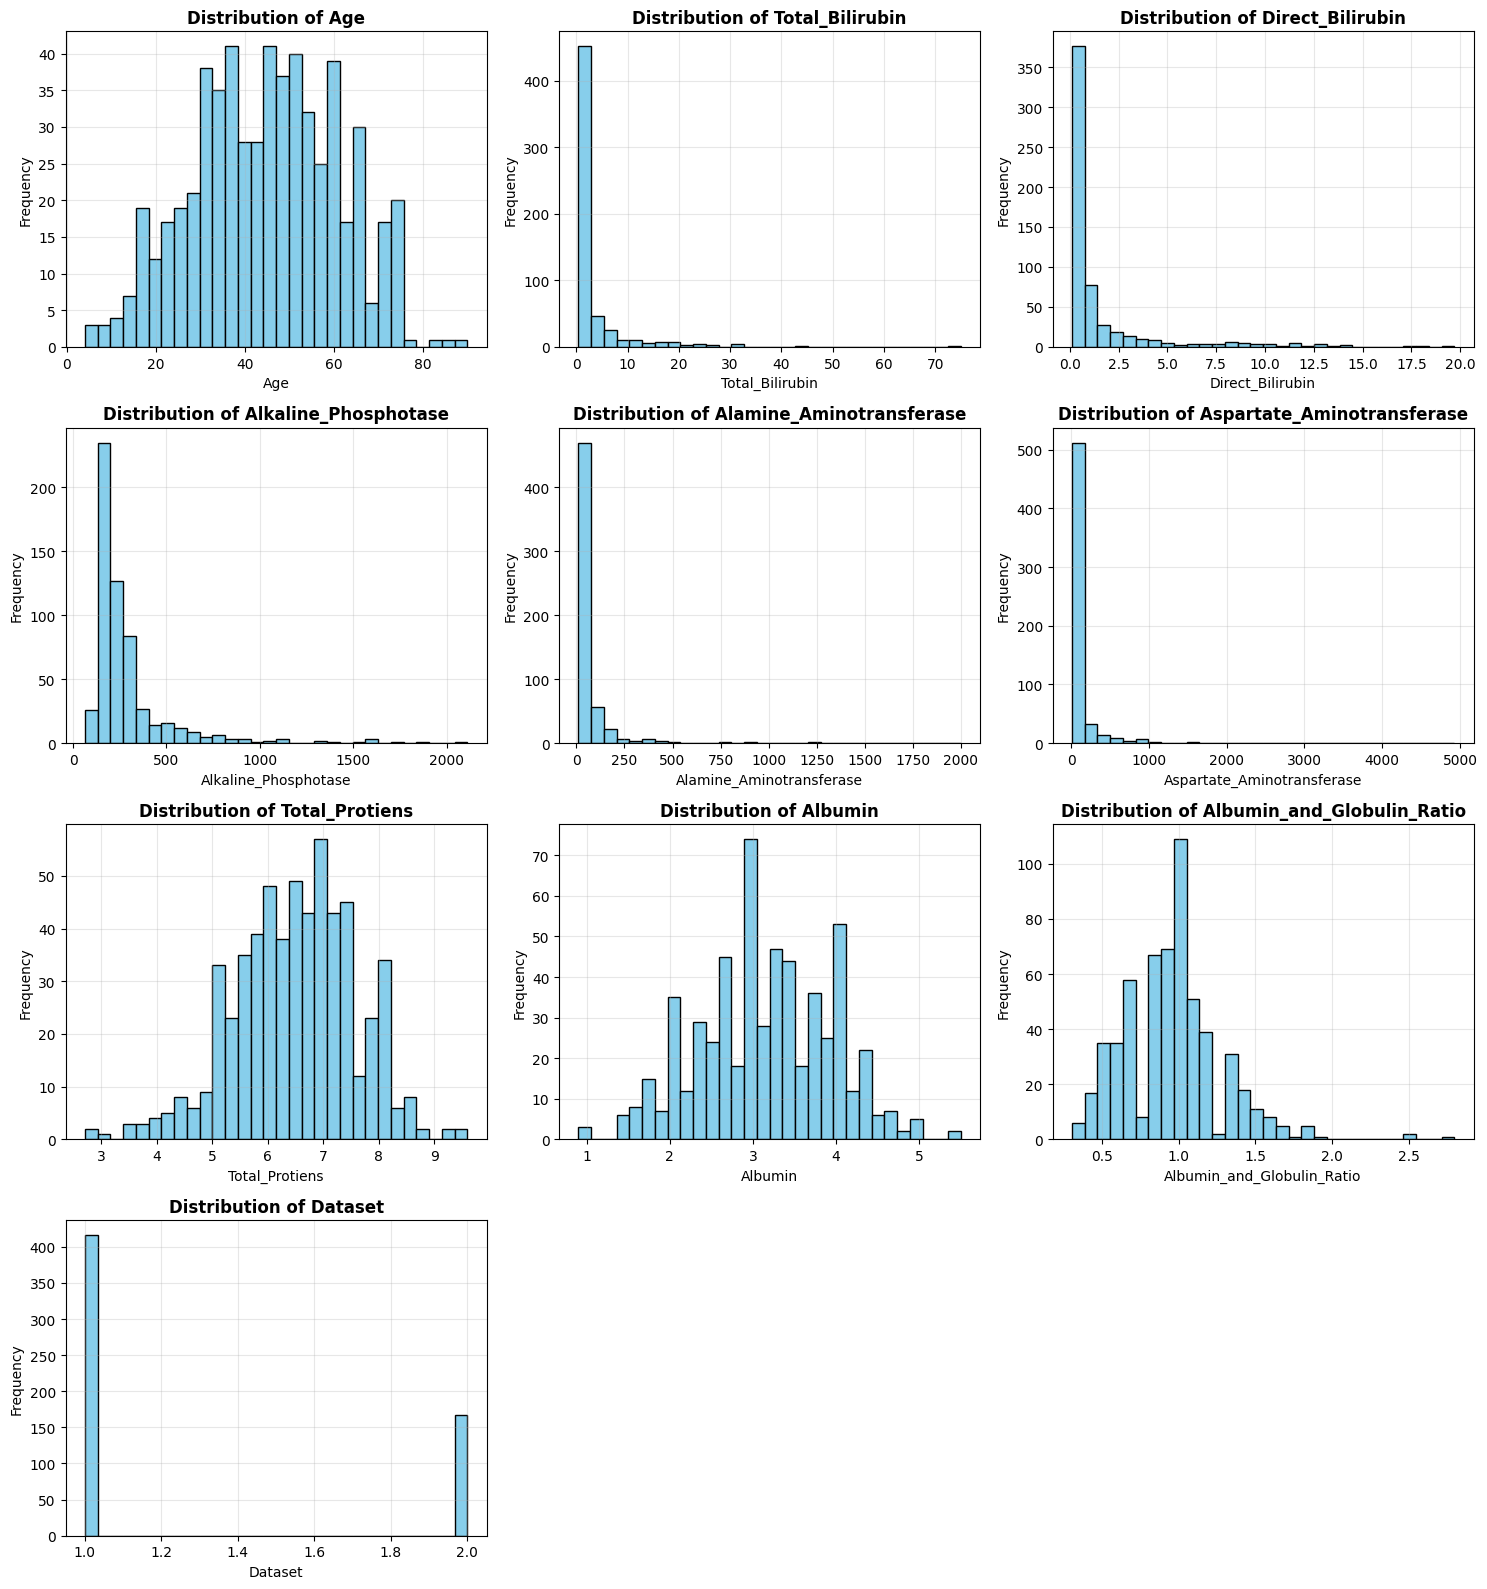

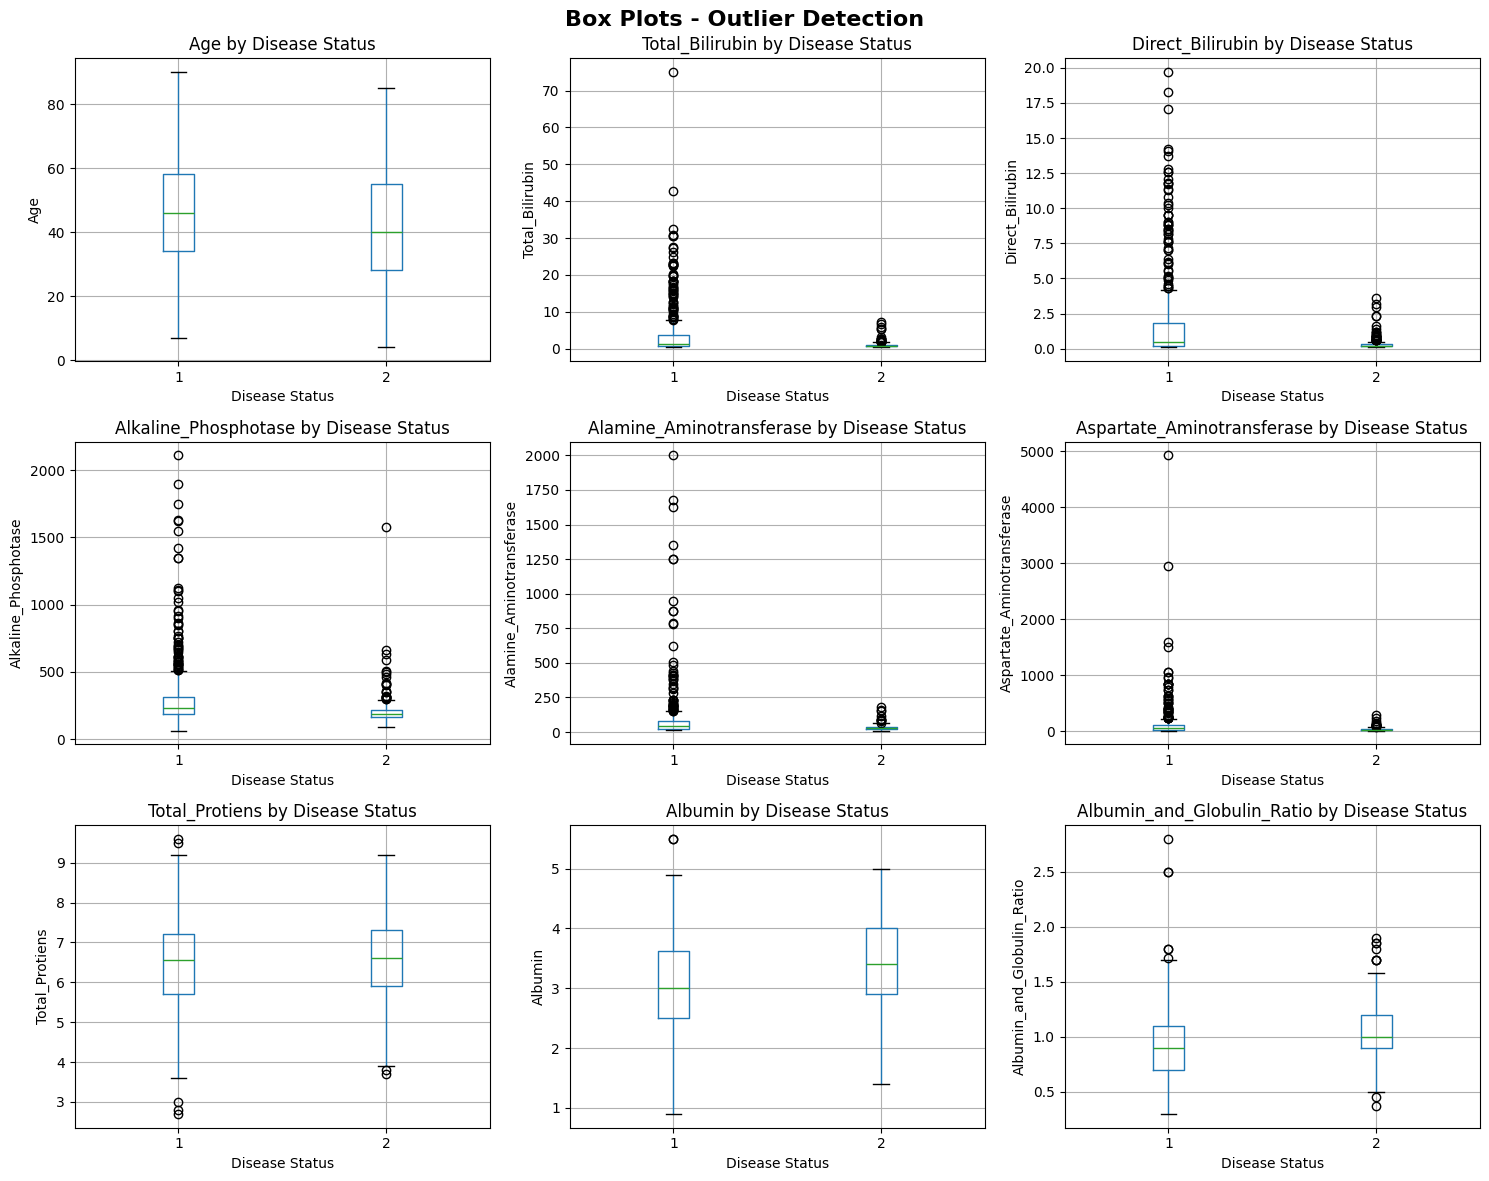

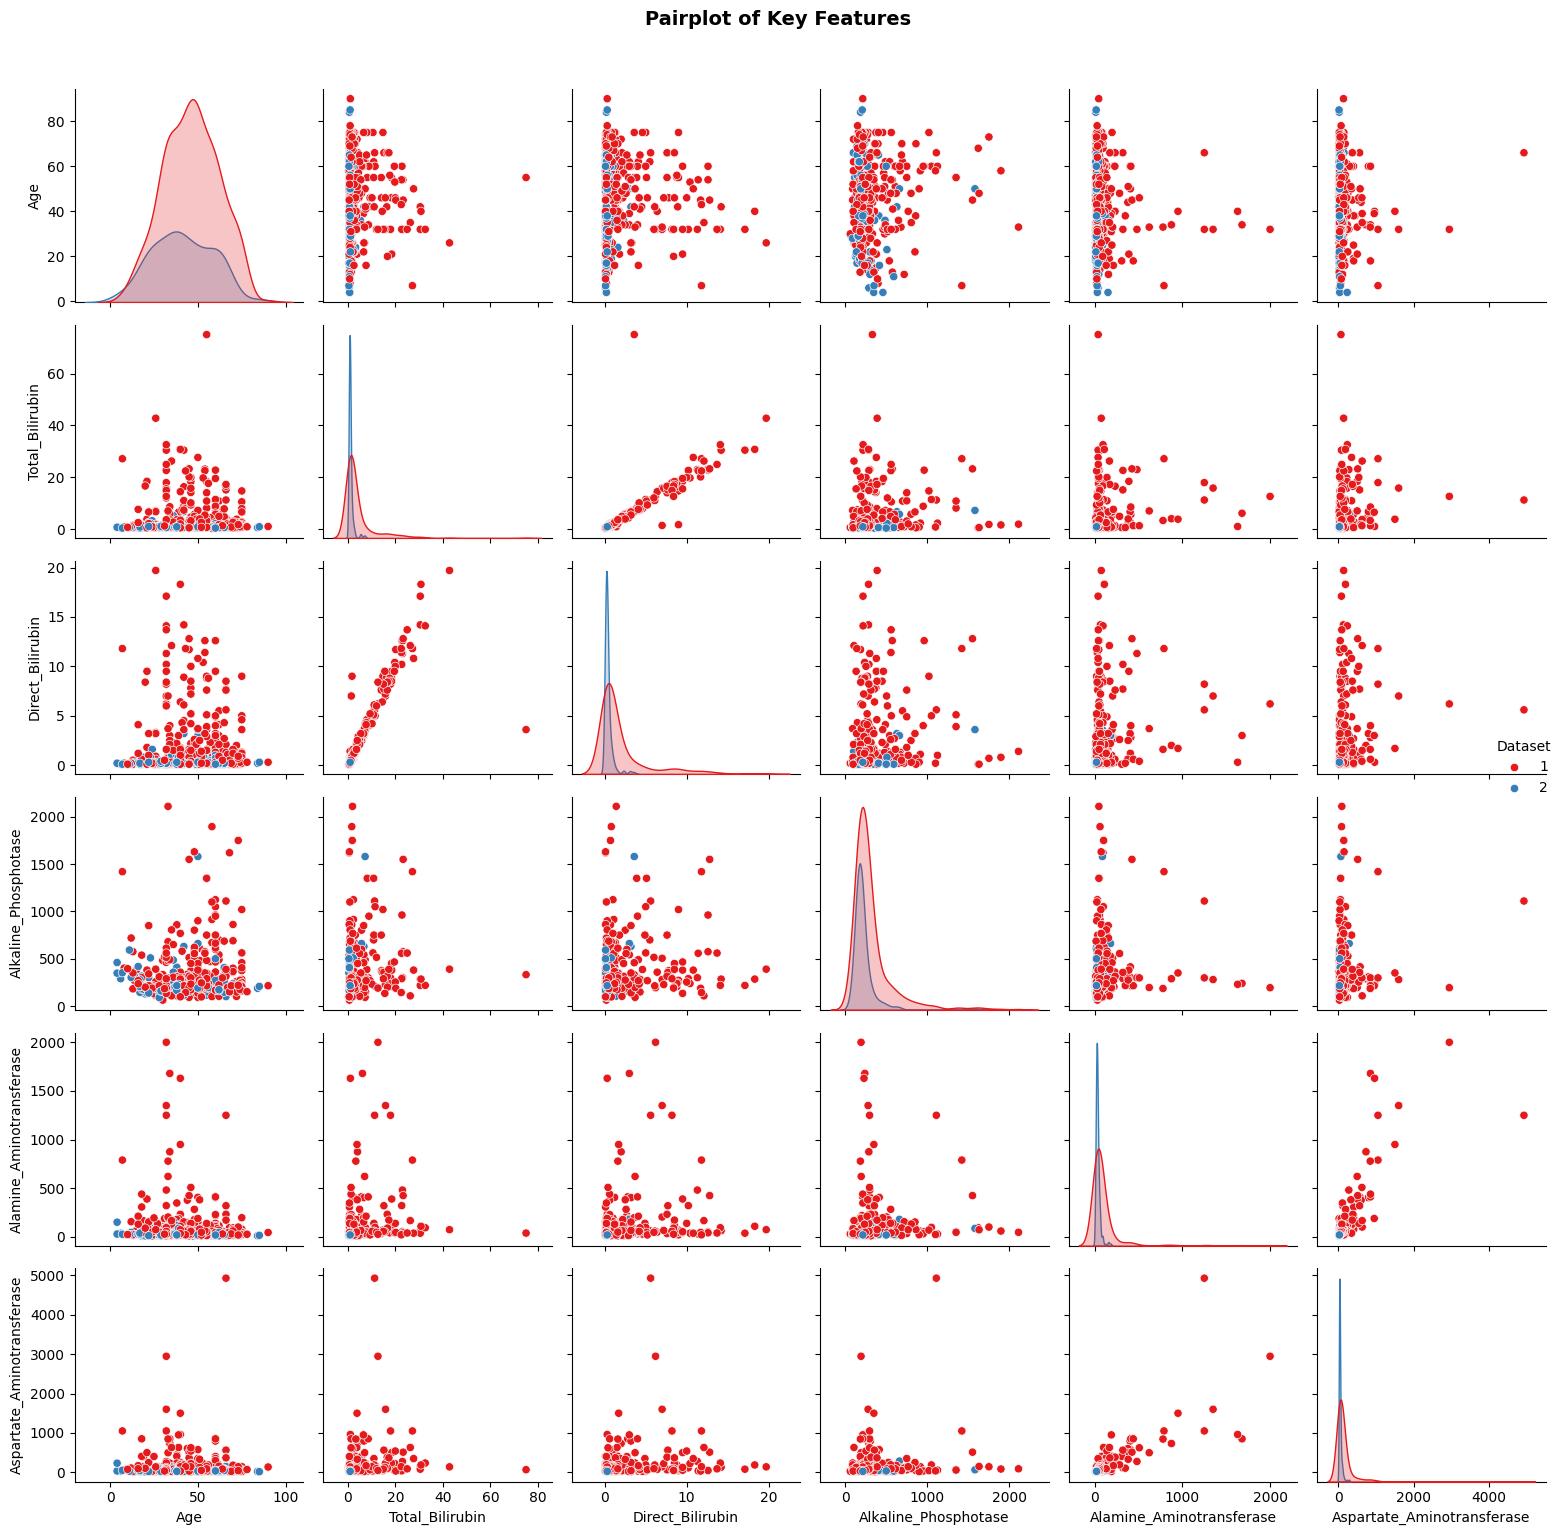

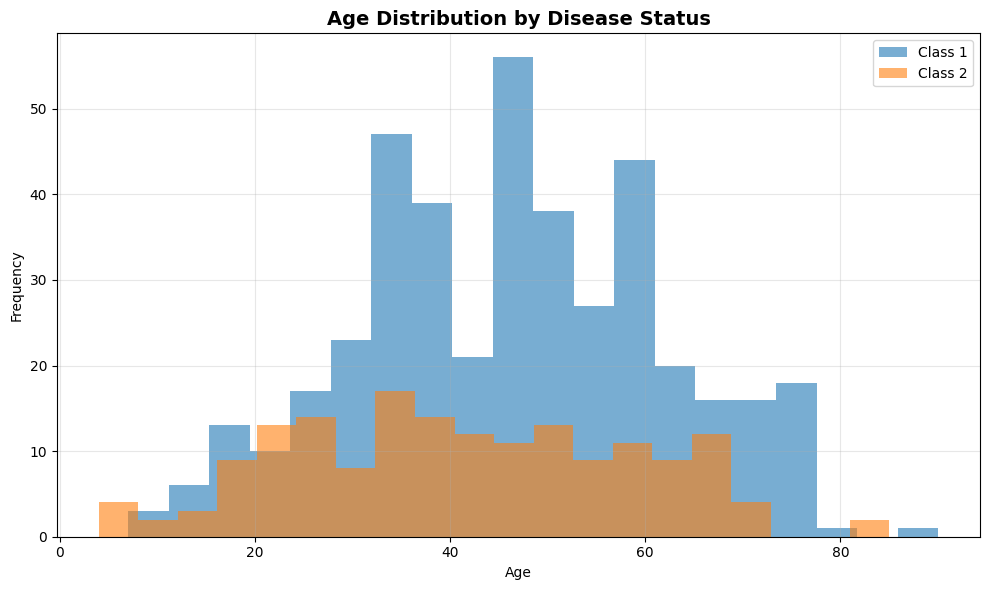

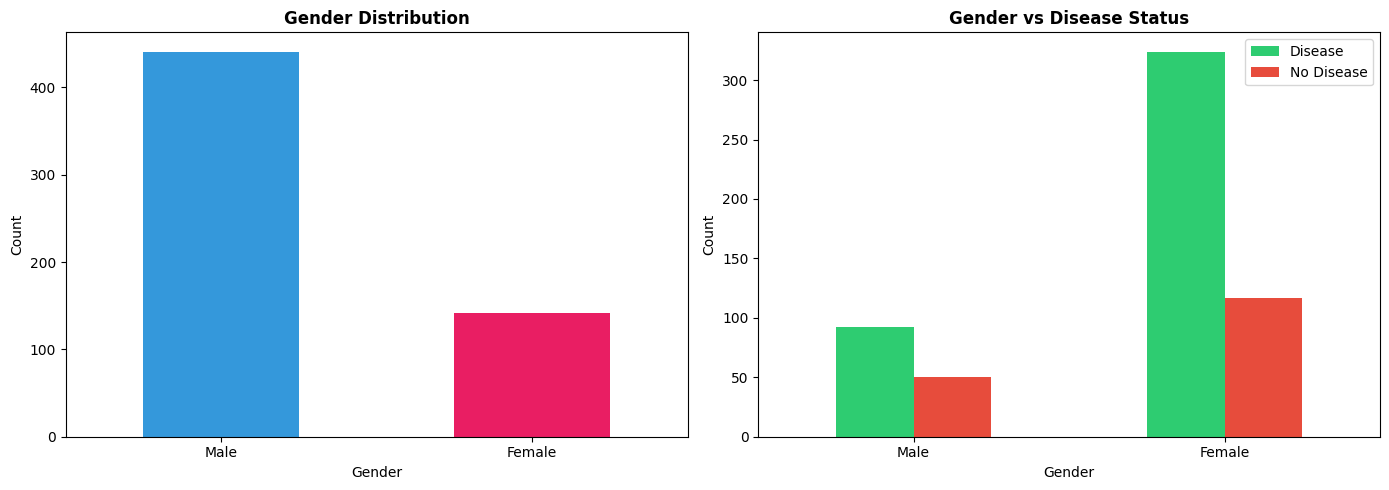

AttributeError: 'LiverDiseasePredictor' object has no attribute 'best_model_name'

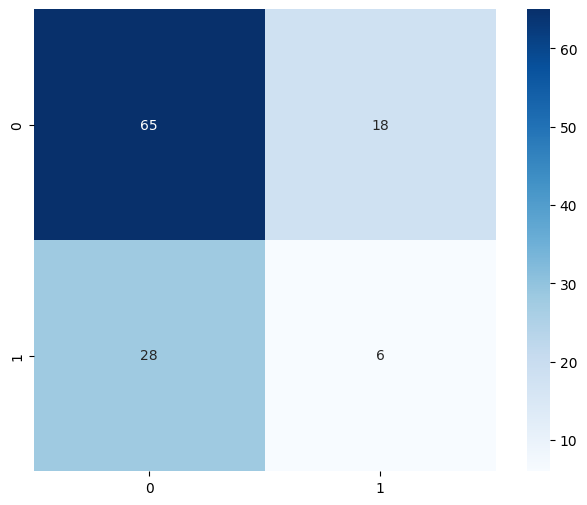

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

class LiverDiseaseVisualizer:
    def __init__(self, predictor):
        self.predictor = predictor
        self.df = predictor.df

    def plot_all_graphs(self):
        """Generate all visualization graphs"""
        self.plot_target_distribution()
        self.plot_missing_values()
        self.plot_correlation_heatmap()
        self.plot_feature_distributions()
        self.plot_box_plots()
        self.plot_pairplot()
        self.plot_age_distribution()
        self.plot_gender_analysis()
        self.plot_confusion_matrix()
        self.plot_roc_curve()
        self.plot_precision_recall_curve()
        self.plot_feature_importance()
        self.plot_model_comparison()

    def plot_target_distribution(self):
        """Bar plot of target variable distribution"""
        plt.figure(figsize=(8, 6))
        target_col = self.df.columns[-1]
        self.df[target_col].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
        plt.title('Distribution of Liver Disease Cases', fontsize=14, fontweight='bold')
        plt.xlabel('Class (1=Disease, 2=No Disease)')
        plt.ylabel('Count')
        plt.xticks(rotation=0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_missing_values(self):
        """Bar plot showing missing values"""
        plt.figure(figsize=(10, 6))
        missing = self.df.isnull().sum()
        missing = missing[missing > 0].sort_values(ascending=False)
        if len(missing) > 0:
            missing.plot(kind='bar', color='coral')
            plt.title('Missing Values in Dataset', fontsize=14, fontweight='bold')
            plt.xlabel('Features')
            plt.ylabel('Number of Missing Values')
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=16)
        plt.tight_layout()
        plt.show()

    def plot_correlation_heatmap(self):
        """Heatmap of feature correlations"""
        plt.figure(figsize=(12, 10))
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        corr_matrix = self.df[numeric_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, square=True, linewidths=1)
        plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_feature_distributions(self):
        """Histograms for all numerical features"""
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
        axes = axes.flatten()

        for idx, col in enumerate(numeric_cols):
            axes[idx].hist(self.df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
            axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
            axes[idx].grid(alpha=0.3)

        # Hide extra subplots
        for idx in range(len(numeric_cols), len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()

    def plot_box_plots(self):
        """Box plots for outlier detection"""
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        target_col = self.df.columns[-1]
        numeric_cols = [col for col in numeric_cols if col != target_col]

        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
        axes = axes.flatten()

        for idx, col in enumerate(numeric_cols):
            self.df.boxplot(column=col, by=target_col, ax=axes[idx])
            axes[idx].set_title(f'{col} by Disease Status')
            axes[idx].set_xlabel('Disease Status')
            axes[idx].set_ylabel(col)

        for idx in range(len(numeric_cols), len(axes)):
            axes[idx].axis('off')

        plt.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_pairplot(self):
        """Pairplot for feature relationships"""
        target_col = self.df.columns[-1]
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns[:6]  # First 6 features
        plot_df = self.df[list(numeric_cols) + [target_col]]
        sns.pairplot(plot_df, hue=target_col, palette='Set1', diag_kind='kde')
        plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_age_distribution(self):
        """Age distribution by disease status"""
        if 'Age' in self.df.columns:
            plt.figure(figsize=(10, 6))
            target_col = self.df.columns[-1]
            for status in self.df[target_col].unique():
                subset = self.df[self.df[target_col] == status] ['Age']
                plt.hist(subset, bins=20, alpha=0.6, label=f'Class {status}')
            plt.title('Age Distribution by Disease Status', fontsize=14, fontweight='bold')
            plt.xlabel('Age')
            plt.ylabel('Frequency')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

    def plot_gender_analysis(self):
        """Gender distribution analysis"""
        if 'Gender' in self.df.columns:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            # Gender count
            self.df['Gender'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e91e63'])
            axes[0].set_title('Gender Distribution', fontweight='bold')
            axes[0].set_xlabel('Gender')
            axes[0].set_ylabel('Count')
            axes[0].set_xticklabels(['Male', 'Female'], rotation=0)

            # Gender vs Disease
            target_col = self.df.columns[-1]
            pd.crosstab(self.df['Gender'], self.df[target_col]).plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
            axes[1].set_title('Gender vs Disease Status', fontweight='bold')
            axes[1].set_xlabel('Gender')
            axes[1].set_ylabel('Count')
            axes[1].set_xticklabels(['Male', 'Female'], rotation=0)
            axes[1].legend(['Disease', 'No Disease'])

            plt.tight_layout()
            plt.show()

    def plot_confusion_matrix(self):
        """Confusion matrix for best model"""
        plt.figure(figsize=(8, 6))
        y_pred = self.predictor.best_model.predict(self.predictor.X_test)
        cm = confusion_matrix(self.predictor.y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, square=True)
        plt.title(f'Confusion Matrix - {self.predictor.best_model_name}', fontsize=14, fontweight='bold')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

    def plot_roc_curve(self):
        """ROC curve for all models"""
        plt.figure(figsize=(10, 8))

        for name, model in self.predictor.models.items():
            if hasattr(model, 'predict_proba'):
                y_proba = model.predict_proba(self.predictor.X_test)[:, 1]
                fpr, tpr, _ = roc_curve(self.predictor.y_test, y_proba, pos_label=1)
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', linewidth=2)

        plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_precision_recall_curve(self):
        """Precision-Recall curve"""
        plt.figure(figsize=(10, 8))

        for name, model in self.predictor.models.items():
            if hasattr(model, 'predict_proba'):
                y_proba = model.predict_proba(self.predictor.X_test)[:, 1]
                precision, recall, _ = precision_recall_curve(self.predictor.y_test, y_proba, pos_label=1)
                plt.plot(recall, precision, label=name, linewidth=2)

        plt.xlabel('Recall', fontsize=12)
        plt.ylabel('Precision', fontsize=12)
        plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_feature_importance(self):
        """Feature importance for Random Forest"""
        if 'Random Forest' in self.predictor.models:
            rf_model = self.predictor.models['Random Forest']
            importances = rf_model.feature_importances_
            indices = np.argsort(importances)[::-1]

            plt.figure(figsize=(12, 6))
            plt.bar(range(len(importances)), importances[indices], color='teal')
            plt.xticks(range(len(importances)),
                      [self.predictor.feature_names[i] for i in indices],
                      rotation=45, ha='right')
            plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
            plt.xlabel('Features')
            plt.ylabel('Importance Score')
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

    def plot_model_comparison(self):
        """Bar chart comparing model accuracies"""
        plt.figure(figsize=(10, 6))
        models = list(self.predictor.results.keys())
        accuracies = list(self.predictor.results.values())

        colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
        bars = plt.bar(models, accuracies, color=colors[:len(models)])

        # Highlight best model
        best_idx = accuracies.index(max(accuracies))
        bars[best_idx].set_color('#9b59b6')
        bars[best_idx].set_edgecolor('black')
        bars[best_idx].set_linewidth(2)

        plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
        plt.xlabel('Models')
        plt.ylabel('Accuracy')
        plt.ylim([0, 1])
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)

        # Add value labels on bars
        for i, v in enumerate(accuracies):
            plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

# Usage:
visualizer = LiverDiseaseVisualizer(predictor)
visualizer.plot_all_graphs()
